# 고속/시외버스 터미널 연간 이용객 순위 IN 서울시
- 2023년 기준 서울 내 있는 고속/시외버스 터미널 별 연간 이용객 순위 매겨서 시각화
- TOP 몇 개 터미널만 추려서 위치 좌표(위도, 경도) 구하기

## 1. 데이터 로드 

### 1. 버스터미널 승하차 순위

- 2023년 연간 총 이용객 기준
1. 서울고속버스터미널: 29456230명
2. 센트럴시티터미널: 17532410명
3. 동서울터미널: 15615795명
4. 서울남부터미널: 8540270명

In [ ]:
import numpy as np
import pandas as pd 


# 데이터 준비
terminals = ['경부고속', '센트럴시티', '동서울','남부']
passengers = [29456230,17532410,15615795,8540270]

# DataFrame 생성
df = pd.DataFrame({'터미널': terminals, '승객수': passengers})

print(df)

     터미널       승객수
0   경부고속  29456230
1  센트럴시티  17532410
2    동서울  15615795
3     남부   8540270


In [3]:
df

,터미널,승객수
0,경부고속,29456230
1,센트럴시티,17532410
2,동서울,15615795
3,남부,8540270


### 2. 시각화

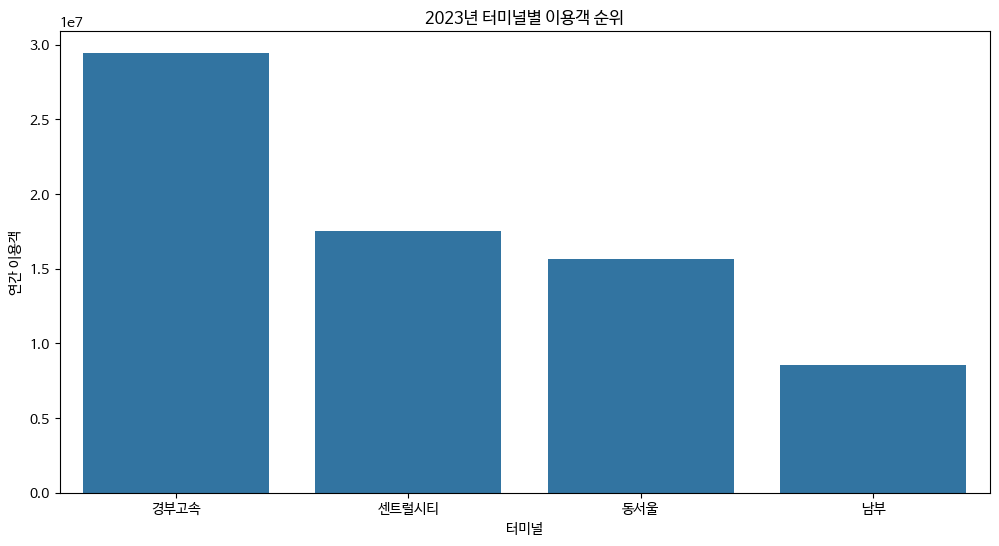

In [5]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

#한글 폰트 설정 
fe = fm.FontEntry(
    fname=r'C:\\Windows\\Fonts\\NanumBarunGothic.ttf',
    name='NanumBarunGothic')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams['font.family'] = 'NanumBarunGothic'  # 한글 폰트 설정
plt.rcParams['axes.unicode_minus'] = False        # 마이너스 깨짐 방지

# 평균 거래가 기준 막대그래프 그리기 
plt.figure(figsize=(12,6))
sns.barplot(data=df, x='터미널', y='승객수')
plt.title('2023년 터미널별 이용객 순위')
plt.xticks(rotation=0)
plt.ylabel('연간 이용객')
plt.show()

## 2. Folium으로 역별 아파트 인근 시세 확인

### 2.1 데이터 로드 및 df 생성

In [6]:
import pandas as pd

# 터미널명과 경도, 위도 데이터
terminals = ['경부고속터미널', '센트럴시티터미널', '동서울터미널']
longitudes = [126.9784, 126.9811, 127.0955]
latitudes = [37.5045, 37.5050, 37.5373]

# DataFrame 생성
df_destination = pd.DataFrame({'터미널명': terminals, '경도': longitudes, '위도': latitudes})

print(df_destination)

       터미널명        경도       위도
0   경부고속터미널  126.9784  37.5045
1  센트럴시티터미널  126.9811  37.5050
2    동서울터미널  127.0955  37.5373


### 2.2 터미널세권 아파트 거리 구하기
- 반경 500m~1km 내의 아파트 중 반경변수를 조절해가면서 역세권 프리미엄 아파트 반경 찾기 

In [ ]:
#반경 변수
metera=1000

In [ ]:
# 데이터프레임의 위도/경도 범위 확인
print("경도 범위:", df_destination['좌표X'].min(), "~", df_destination['좌표X'].max())
print("위도 범위:", df_destination['좌표Y'].min(), "~", df_destination['좌표Y'].max())


경도 범위: 126.7983185 ~ 127.1799976
위도 범위: 37.4478428 ~ 37.6877248


In [46]:
import pandas as pd
from geopy.distance import distance

# 두 데이터프레임 간 거리 계산 및 필터링
results = []
for _, station in df1.iterrows():
    for _, apt in df2.iterrows():
        dist = distance(
            (station['위도'], station['경도']),
            (apt['좌표Y'], apt['좌표X'])
        ).m
        if dist <= metera:
            results.append({
                '아파트명': apt['아파트명'],
                '경도': apt['좌표X'],
                '위도': apt['좌표Y'],
                'target': apt['target'],
                '근처거리': dist,
                '근처 기차역': station['역']
            })

# 결과 데이터프레임 생성
df3 = pd.DataFrame(results).rename(columns={
    '근처 기차역': '근처 기차역(기준역)'
}).reset_index(drop=True)

df3.head()

ValueError: Point coordinates must be finite. (nan, nan, 0.0) has been passed as coordinates.

### 2.3 그래프로 시각화 

In [ ]:
#서울시 좌표 활성화 
import folium
m = folium.Map(location=[37.5642135, 127.0016985], zoom_start=11)
m

In [9]:
# 기차역 좌표 데이터프레임: df1 (columns: 'name', 'lat', 'lon') 추가
for idx, row in df1.iterrows():
    folium.Marker(
        location=[row['위도'], row['경도']],
        popup=row['역명'],
        icon=folium.Icon(color='red', icon='train')
    ).add_to(m)

In [10]:
m